In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Regression and ML models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Folder path
data_folder = "./Data"

###  Dataset
-------

In [2]:
# Get list of CSV files in the folder
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
dataframes = {}
for file in csv_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)
    dataframes[file] = df  # Store DataFrame with filename as key

In [3]:
if len(csv_files) < 4:
    raise ValueError("Oops! Less than 4 CSV files found.")
csv_files = csv_files[:4]

with pd.ExcelWriter("Data_Summary_Report.xlsx") as writer:
    for file in csv_files:
        path = os.path.join(data_folder, file)
        df = pd.read_csv(path)

        print(f"\nSummary for '{file}': {df.shape[0]} rows, {df.shape[1]} columns")

        summary_data = []
        for col in df.columns:
            dtype = df[col].dtype
            if pd.api.types.is_numeric_dtype(df[col]):
                stats = df[col].describe()
                desc = f"Count: {int(stats['count'])}, Mean: {stats['mean']:.2f}, Min: {stats['min']}, Max: {stats['max']}"
            else:
                unique = df[col].nunique()
                samples = ", ".join(map(str, df[col].dropna().unique()[:3]))
                desc = f"Unique: {unique}, Examples: {samples}"

            summary_data.append({"Column": col, "Type": str(dtype), "Summary": desc})

        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))

        print("\n" + "-"*30 + f" Finished '{file}' " + "-"*30 + "\n")

        summary_df.to_excel(writer, sheet_name=file[:31], index=False)



Summary for 'item.csv': 927 rows, 5 columns
    Column   Type                                                                                                    Summary
      code  int64                                       Count: 927, Mean: 5534601766.58, Min: 111112360.0, Max: 9999985766.0
descrption object Unique: 872, Examples: AUNT JEM ORIGINAL PANCAKE MIX, A/JEM COMPLETE PANCAKE MI, AJ BUTTERMILK PANCAKE MIX
      type object                                                                Unique: 4, Examples: Type 1, Type 2, Type 3
     brand object                                                      Unique: 131, Examples: Aunt Jemima, Bisquick, Bruce's
      size object                                                               Unique: 146, Examples: 2 LB, 32    OZ, 32 OZ

------------------------------ Finished 'item.csv' ------------------------------


Summary for 'promotion.csv': 351372 rows, 6 columns
      Column   Type                                                 

## 🔍 Forecasting Sales During Promotions

---

**Note:**  
I merged the CSV files and created a `promotion_active` column:  
- Set to `1` if either `feature` or `display` is active  
- Set to `0` otherwise

Only rows with `promotion_active == 1` are used for forecasting.

####  Step 1: Data Pre-processing

In [4]:
promotion_df = pd.read_csv("./Data/promotion.csv")
sales_df = pd.read_csv("./Data/sales.csv")
# Rename for consistency
promotion_df.rename(columns={"supermarkets": "supermarket"}, inplace=True)

# Ensure 'supermarket' is integer type in both dataframes for smooth merging
promotion_df["supermarket"] = promotion_df["supermarket"].astype(int)
sales_df["supermarket"] = sales_df["supermarket"].astype(int)

# Keep the first promotion record per supermarket (to avoid duplicates)
promo_summary = promotion_df.groupby("supermarket")[["feature", "display"]].first().reset_index()

# Merge sales data with promotion info on 'supermarket'
merged_df = sales_df.merge(promo_summary, on="supermarket", how="left")

# Report how many sales rows have promotion info
promo_rows_count = merged_df["feature"].notna().sum()
print(f"Sales rows with promotion info: {promo_rows_count}")
merged_df.head()

Sales rows with promotion info: 1038910


,code,amount,units,time,province,week,customerId,supermarket,basket,day,voucher,feature,display
0,7680850106,0.80,1,1100,2,1,125434,244,1,1,0,Not on Feature,In-Shelf
1,3620000470,3.59,1,1100,2,1,125434,244,1,1,0,Not on Feature,In-Shelf
2,1800028064,2.25,1,1137,2,1,108320,244,2,1,0,Not on Feature,In-Shelf
3,9999985067,0.85,1,1148,2,1,162016,244,3,1,0,Not on Feature,In-Shelf
4,9999985131,2.19,1,1323,2,1,89437,244,4,1,0,Not on Feature,In-Shelf


In [5]:
merged_df.shape

(1048575, 13)

In [6]:
data_folder = "./Data"
item_df = pd.read_csv(os.path.join(data_folder, 'item.csv'))

# Assuming merged_df is already loaded and contains 'code' column
# Merge item data onto merged_df by 'code'
final_df = pd.merge(
    merged_df,
    item_df,
    on='code',
    how='left'  # Keep all rows in merged_df, add item info where available
)
final_df.head()

,code,amount,units,time,province,week,customerId,supermarket,basket,day,voucher,feature,display,descrption,type,brand,size
0,7680850106,0.80,1,1100,2,1,125434,244,1,1,0,Not on Feature,In-Shelf,BARILLA ANGEL HAIR,Type 2,Barilla,16 OZ
1,3620000470,3.59,1,1100,2,1,125434,244,1,1,0,Not on Feature,In-Shelf,BERTOLLI TOM&BASIL SAUCE,Type 3,Bertolli,24 OZ
2,1800028064,2.25,1,1137,2,1,108320,244,2,1,0,Not on Feature,In-Shelf,H J PANCK BTRMLK COMP MIX,Type 1,Hungry Jack,
3,9999985067,0.85,1,1148,2,1,162016,244,3,1,0,Not on Feature,In-Shelf,PRIVATE LABEL VERMICELLI,Type 2,Private Label,16 OZ
4,9999985131,2.19,1,1323,2,1,89437,244,4,1,0,Not on Feature,In-Shelf,PRIVATE LABEL IMPORTED LASAGNA,Type 2,Private Label Premium,16 OZ


In [7]:
final_df.shape

(1048575, 17)

In [8]:
def preprocess_sales_data(df):
    """
    Preprocess sales DataFrame:
    - Handle missing promotion data
    - Create binary promotion flag
    - Encode categorical columns
    - Log-transform amount
    - Drop irrelevant columns
    - Sort and reset index
    """
    
    # 1. Fill missing promotion info with explicit labels
    df['feature'].fillna('No Feature', inplace=True)
    df['display'].fillna('No Display', inplace=True)

    # 2. Create 'promotion_active' flag (1 if any promotion, else 0)
    df['promotion_active'] = ((df['feature'] != 'No Feature') | (df['display'] != 'No Display')).astype(int)

    # 3. Assume 'week' and 'day' numeric for temporal info; no date conversion here
    
    # 4. Encode categorical variables as category codes
    categorical_cols = ['feature', 'display', 'province', 'supermarket']
    for col in categorical_cols:
        df[col] = df[col].astype('category').cat.codes

    # 5. Log-transform 'amount' to reduce skewness (if needed)
    df['log_amount'] = np.log1p(df['amount'])

    # 6. Drop columns unlikely useful or that may leak info
    drop_cols = ['customerId', 'basket', 'voucher', 'time']
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

    # 7. Sort by supermarket, week, day to maintain time order
    df.sort_values(by=['supermarket', 'week', 'day'], inplace=True)

    # 8. Reset index after sorting
    df.reset_index(drop=True, inplace=True)

    return df

# Example usage:
processed_df = preprocess_sales_data(merged_df)
processed_df.head()

,code,amount,units,province,week,supermarket,day,feature,display,promotion_active,log_amount
0,9999985133,0.78,2,0,1,0,1,7,5,1,0.576613
1,3000005300,4.58,2,0,1,0,1,7,5,1,1.719189
2,3620000444,1.99,1,0,1,0,1,7,5,1,1.095273
3,5100002549,1.99,1,0,1,0,1,7,5,1,1.095273
4,9999985027,4.47,3,0,1,0,1,7,5,1,1.699279


In [11]:
import xgboost as xgb
import lightgbm as lgb
def add_lag_features(df, group_col, target_col, lags=[1,2,3], fill_na=None):
    df = df.sort_values(by=[group_col, 'week', 'day'])
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df.groupby(group_col)[target_col].shift(lag)
    if fill_na is not None:
        df.fillna(fill_na, inplace=True)
    return df

def encode_categoricals(df, columns):
    encoders = {}
    for col in columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
    return df, encoders

def train_and_evaluate(models, X_train, y_train, X_test, y_test, scale_numeric=False, numeric_cols=None):
    results = []
    scaler = StandardScaler()
    if scale_numeric and numeric_cols:
        X_train_num = scaler.fit_transform(X_train[numeric_cols])
        X_test_num = scaler.transform(X_test[numeric_cols])
        # Replace numeric cols with scaled values but keep categorical unchanged
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        X_train_scaled[numeric_cols] = X_train_num
        X_test_scaled[numeric_cols] = X_test_num
    else:
        X_train_scaled, X_test_scaled = X_train, X_test
    
    for name, model in models.items():
        if name in ['LinearRegression', 'NeuralNetwork']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results.append({'Model': name, 'RMSE': rmse, 'R²': r2})
    
    return pd.DataFrame(results).sort_values(by='RMSE')

# --- Usage example ---
promo_df = processed_df[processed_df['promotion_active'] == 1].copy()
promo_df = add_lag_features(promo_df, 'code', 'units', fill_na=0)
promo_df, encoders = encode_categoricals(promo_df, ['code', 'feature', 'display', 'province', 'supermarket'])

features = ['code', 'amount', 'province', 'week', 'supermarket', 'day', 'feature', 'display', 'promotion_active',
            'units_lag_1', 'units_lag_2', 'units_lag_3']
target = 'units'

X = promo_df[features]
y = promo_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=42, n_jobs=-1)
}

numeric_cols = ['amount', 'week', 'day', 'promotion_active', 'units_lag_1', 'units_lag_2', 'units_lag_3']
results_df = train_and_evaluate(models, X_train, y_train, X_test, y_test, scale_numeric=True, numeric_cols=numeric_cols)
print(results_df.to_string(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1015
[LightGBM] [Info] Number of data points in the train set: 831128, number of used features: 11
[LightGBM] [Info] Start training from score 1.188256
           Model     RMSE       R²
    RandomForest 0.146143 0.924401
        LightGBM 0.202814 0.854403
         XGBoost 0.233738 0.806617
LinearRegression 0.525205 0.023624


### 📊 Impact of Feature & Display Promotions on Sales

---

`promotion_active` = 1 if feature or display promotion is active, else 0.  
Analysis uses only `promotion_active == 1` periods.

In [100]:
class PromotionAnalysis:
    def __init__(self, df):
        """
        df: pandas DataFrame with columns:
            'units', 'feature', 'display', 'province', 'supermarket', 'week'
        """
        self.df = df.copy()
        self._prepare_data()
    def print_unique_promotions(self):
        print("🧾 Unique Feature Types:")
        print(self.df['feature'].unique())
        print("\n🧾 Unique Display Types:")
        print(self.df['display'].unique())
    def _prepare_data(self):
        self.df['feature'] = self.df['feature'].fillna('No Feature')
        self.df['display'] = self.df['display'].fillna('No Display')
    
    def summary_stats(self):
        print("🔍 Average Units Sold by Feature:")
        feature_avg = self.df.groupby('feature')['units'].mean().sort_values(ascending=False)
        print(feature_avg.to_frame().reset_index().rename(columns={'units':'Average Units Sold'}))
        print("\n🔍 Average Units Sold by Display:")
        display_avg = self.df.groupby('display')['units'].mean().sort_values(ascending=False)
        print(display_avg.to_frame().reset_index().rename(columns={'units':'Average Units Sold'}))
    
    def plot_overview(self):
        plt.figure(figsize=(14,6))
        
        # Total sales per feature
        feature_sales = self.df.groupby('feature')['units'].sum().sort_values(ascending=False)
        plt.subplot(1,2,1)
        plt.pie(
            feature_sales,
            labels=feature_sales.index,
            autopct='%1.1f%%',
            startangle=140,
            pctdistance=0.85,
            labeldistance=1.1,
            wedgeprops=dict(width=0.4),
            textprops={'fontsize': 9}
        )
        plt.title('Sales Distribution by Feature')
        plt.axis('equal')  # Equal aspect ratio ensures pie is circular.

        # Total sales per display type
        display_sales = self.df.groupby('display')['units'].sum().sort_values(ascending=False)
        plt.subplot(1,2,2)
        plt.pie(
            display_sales,
            labels=display_sales.index,
            autopct='%1.1f%%',
            startangle=140,
            pctdistance=0.85,
            labeldistance=1.1,
            wedgeprops=dict(width=0.4),
            textprops={'fontsize': 9}
        )
        plt.title('Sales Distribution by Display Type')
        plt.axis('equal')

        plt.tight_layout()
        plt.show()
    def plot_top_items_by_promotion(self, top_n=5):
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # --- Top items by FEATURE (horizontal barplot, sorted descending for top to bottom) ---
        top_feature_items = (
            self.df.groupby(['feature', 'code', 'descrption'])['units']
            .sum()
            .reset_index()
            .sort_values('units', ascending=False)  # descending for top bars first
        )
        top_feature_items = (
            top_feature_items.groupby('feature')
            .head(top_n)
            .sort_values('units', ascending=False)  # descending to keep order
        )

        base_feature_palette = {
            'Interior Page Feature': '#003366',  # dark blue
            'Not on Feature': '#CC0000',         # red
        }
        top_feature_items['color'] = top_feature_items['feature'].map(base_feature_palette).fillna('lightgrey')

        axes[0].barh(
            top_feature_items['descrption'],
            top_feature_items['units'],
            color=top_feature_items['color'],
            edgecolor='black',
            linewidth=1.5
        )
        axes[0].invert_yaxis()  # This makes highest units appear at the top
        axes[0].set_title(f"Top Items by Feature Promotion")
        axes[0].set_xlabel("Units Sold")
        axes[0].set_ylabel("Item Description")

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#003366', edgecolor='black', label='Interior Page Feature'),
            Patch(facecolor='#CC0000', edgecolor='black', label='Not on Feature'),
            Patch(facecolor='lightgrey', edgecolor='black', label='Other Features')
        ]
        axes[0].legend(handles=legend_elements, loc='lower center', fontsize='small', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.3))

        # --- Top items by DISPLAY (horizontal barplot) ---
        top_display_items = (
            self.df.groupby(['display', 'code', 'descrption'])['units']
            .sum()
            .reset_index()
            .sort_values('units', ascending=False)
        )
        top_display_items = (
            top_display_items.groupby('display')
            .head(top_n)
            .sort_values('units', ascending=False)
        )

        base_display_palette = {
            'Not on Display': '#990000',  # dark red
            'On Display': '#666666'       # grey
        }
        top_display_items['color'] = top_display_items['display'].map(base_display_palette).fillna('lightgrey')

        axes[1].barh(
            top_display_items['descrption'],
            top_display_items['units'],
            color=top_display_items['color'],
            edgecolor='black',
            linewidth=1.5
        )
        axes[1].invert_yaxis()  # highest on top
        axes[1].set_title(f"Top  Items by Display Promotion")
        axes[1].set_xlabel("Units Sold")
        axes[1].set_ylabel("Item Description")

        legend_elements_disp = [
            Patch(facecolor='#990000', edgecolor='black', label='Not on Display'),
            Patch(facecolor='#666666', edgecolor='black', label='On Display'),
            Patch(facecolor='lightgrey', edgecolor='black', label='Other Displays')
        ]
        axes[1].legend(handles=legend_elements_disp, loc='lower center', fontsize='small', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.3))

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()

        # Heatmap same as before
        plt.figure(figsize=(10, 6))
        heatmap_data = (
            self.df.groupby(['feature', 'display'])['units']
            .sum()
            .unstack(fill_value=0)
        )
        sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
        plt.title("Heatmap of Units Sold by Feature and Display")
        plt.xlabel("Display")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()




            
    def plot_display_impact(self):
        sns.set_theme(style="whitegrid")
        df = self.df.copy()

        # Total sales per display (bar)
        display_total = df.groupby('display')['units'].sum().sort_values(ascending=False).reset_index()

        # Line plot: Sales trend over weeks for top 5 displays by total sales
        top_displays = display_total['display'].head(5).tolist()
        df_top = df[df['display'].isin(top_displays)]

        plt.figure(figsize=(18,5))

        # 1. Bar Chart: Total sales per display
        plt.subplot(1,3,1)
        sns.barplot(data=display_total, x='units', y='display', palette='Greens_d')
        plt.title("Total Sales by Display Type")
        plt.xlabel("Total Units Sold")
        plt.ylabel("Display Type")
        for i, v in enumerate(display_total['units']):
            plt.text(v + max(display_total['units'])*0.01, i, f"{v:,}", va='center')

        # 2. Box Plot: Sales distribution by display
        plt.subplot(1,3,2)
        sns.boxplot(data=df, x='units', y='display', order=display_total['display'], palette='Greens')
        plt.title("Sales Distribution by Display Type")
        plt.xlabel("Units Sold")
        plt.ylabel(None)

        # 3. Line Chart: Weekly sales trend for top 5 displays
        plt.subplot(1,3,3)
        sns.lineplot(data=df_top, x='week', y='units', hue='display', marker='o', palette='tab10')
        plt.title("Weekly Sales Trend for Top 5 Displays")
        plt.xlabel("Week")
        plt.ylabel("Units Sold")
        plt.legend(title='Display', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        plt.show()
    def plot_feature_impact(self):
        sns.set_theme(style="whitegrid")
        df = self.df.copy()

        # Total sales per feature (bar)
        feature_total = df.groupby('feature')['units'].sum().sort_values(ascending=False).reset_index()

        # Boxplot data: distribution of sales units per feature
        # No aggregation needed, just raw df data with 'feature' and 'units'

        # Line plot: Sales trend over weeks for top 5 features by total sales
        top_features = feature_total['feature'].head(5).tolist()
        df_top = df[df['feature'].isin(top_features)]

        plt.figure(figsize=(18,5))

        # 1. Bar Chart: Total sales per feature
        plt.subplot(1,3,1)
        sns.barplot(data=feature_total, x='units', y='feature', palette='Blues_d')
        plt.title("Total Sales by Promotional Feature")
        plt.xlabel("Total Units Sold")
        plt.ylabel("Feature")
        for i, v in enumerate(feature_total['units']):
            plt.text(v + max(feature_total['units'])*0.01, i, f"{v:,}", va='center')

        # 2. Box Plot: Sales distribution by feature
        plt.subplot(1,3,2)
        sns.boxplot(data=df, x='units', y='feature', order=feature_total['feature'], palette='Blues')
        plt.title("Sales Distribution by Promotional Feature")
        plt.xlabel("Units Sold")
        plt.ylabel(None)

        # 3. Line Chart: Weekly sales trend for top 5 features
        plt.subplot(1,3,3)
        sns.lineplot(data=df_top, x='week', y='units', hue='feature', marker='o', palette='tab10')
        plt.title("Weekly Sales Trend for Top 5 Features")
        plt.xlabel("Week")
        plt.ylabel("Units Sold")
        plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        plt.show()
    def run_regression(self):
        sns.set_theme(style="whitegrid")
        df_reg = self.df.copy()
        for col in ['feature', 'display', 'province', 'supermarket']:
            df_reg[col] = df_reg[col].astype('category').cat.codes

        X_cols = ['feature', 'display', 'province', 'supermarket', 'week']
        X = df_reg[X_cols]
        y = df_reg['units']

        model = LinearRegression()
        model.fit(X, y)
        coefs = pd.DataFrame({'Feature': X_cols, 'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=True)

        plt.figure(figsize=(8,5))

        # Colors: green for positive, red for negative
        colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs['Coefficient']]

        ax = sns.barplot(x='Coefficient', y='Feature', data=coefs, palette=colors)

        plt.title('Regression Coefficients: Impact on Units Sold', fontsize=14)
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature')

        # Adjust x limits to give space for text labels
        x_min, x_max = coefs['Coefficient'].min(), coefs['Coefficient'].max()
        padding = (x_max - x_min) * 0.1
        plt.xlim(x_min - padding, x_max + padding)

        # Annotate coefficient values on bars
        for i, (coef, feature) in enumerate(zip(coefs['Coefficient'], coefs['Feature'])):
            x_pos = coef + (padding * 0.1 if coef > 0 else -padding * 0.1)
            ha = 'left' if coef > 0 else 'right'
            ax.text(x_pos, i, f"{coef:.3f}", va='center', ha=ha, fontsize=10, color='black')

        plt.tight_layout()
        plt.show()

        print("📊 Regression coefficients (sorted by impact):")
        print(coefs.to_string(index=False))

        return model, coefs
        return model, coefs
# Usage
analyzer = PromotionAnalysis(final_df)
analyzer.summary_stats()

🔍 Average Units Sold by Feature:
                   feature  Average Units Sold
0       Wrap Front Feature            1.209553
1  Interior Page Line Item            1.207005
2               No Feature            1.196999
3        Wrap Back Feature            1.195860
4    Wrap Interior Feature            1.195287
5           Not on Feature            1.187247
6       Front Page Feature            1.185576
7    Interior Page Feature            1.185211

🔍 Average Units Sold by Display:
                       display  Average Units Sold
0                     In-Aisle            1.197391
1         Promo/Seasonal Aisle            1.197113
2                   No Display            1.196999
3           Side-Aisle End Cap            1.196312
4   Secondary Location Display            1.193441
5                   Store Rear            1.191374
6               Not on Display            1.188587
7                 Rear End Cap            1.186645
8                     In-Shelf            1.184095


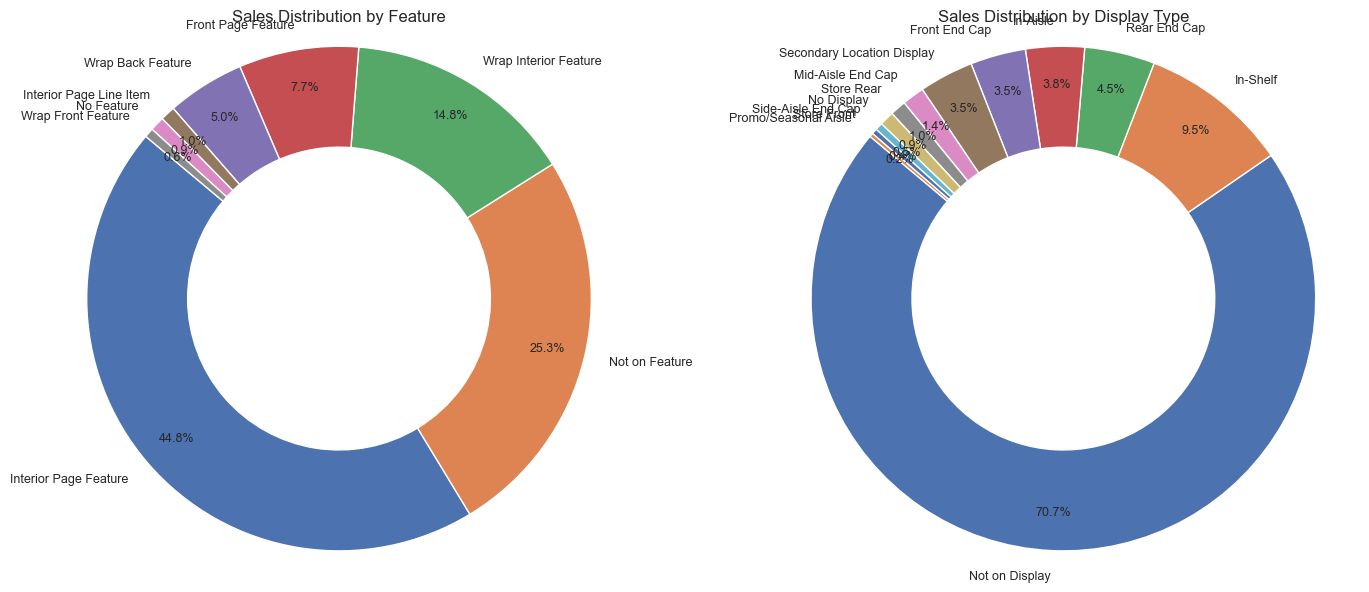

In [80]:
analyzer.plot_overview()

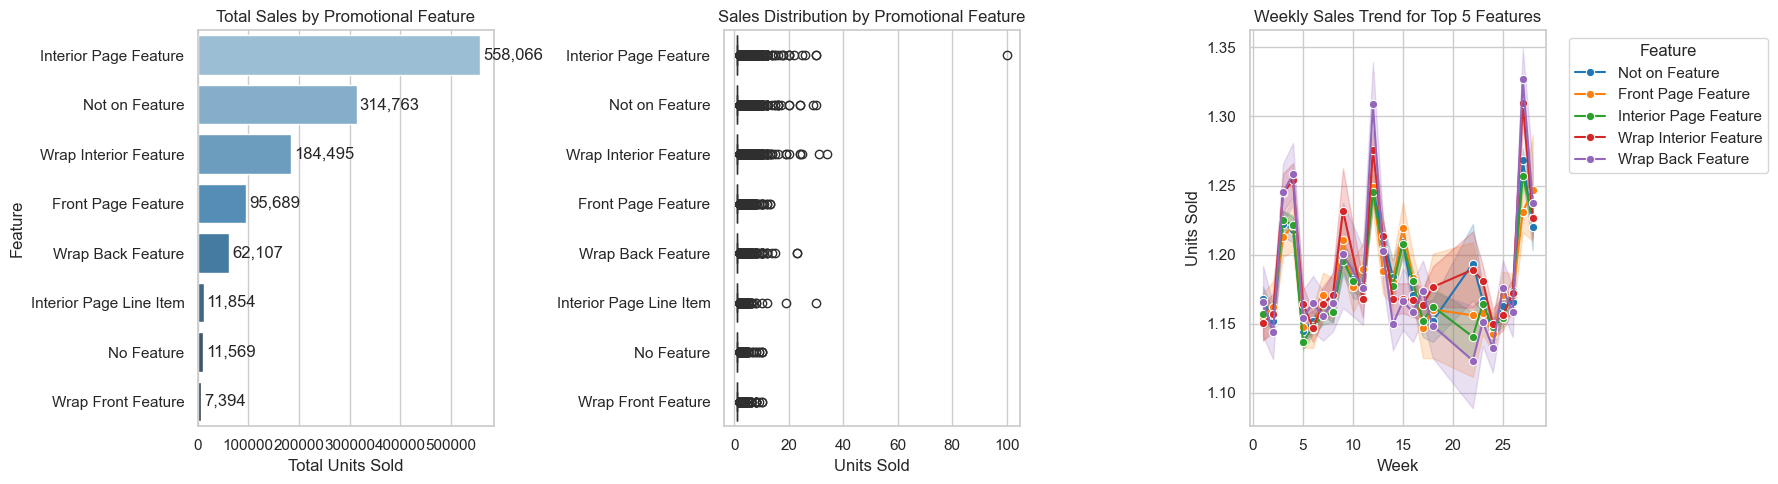

In [81]:
analyzer.plot_feature_impact()

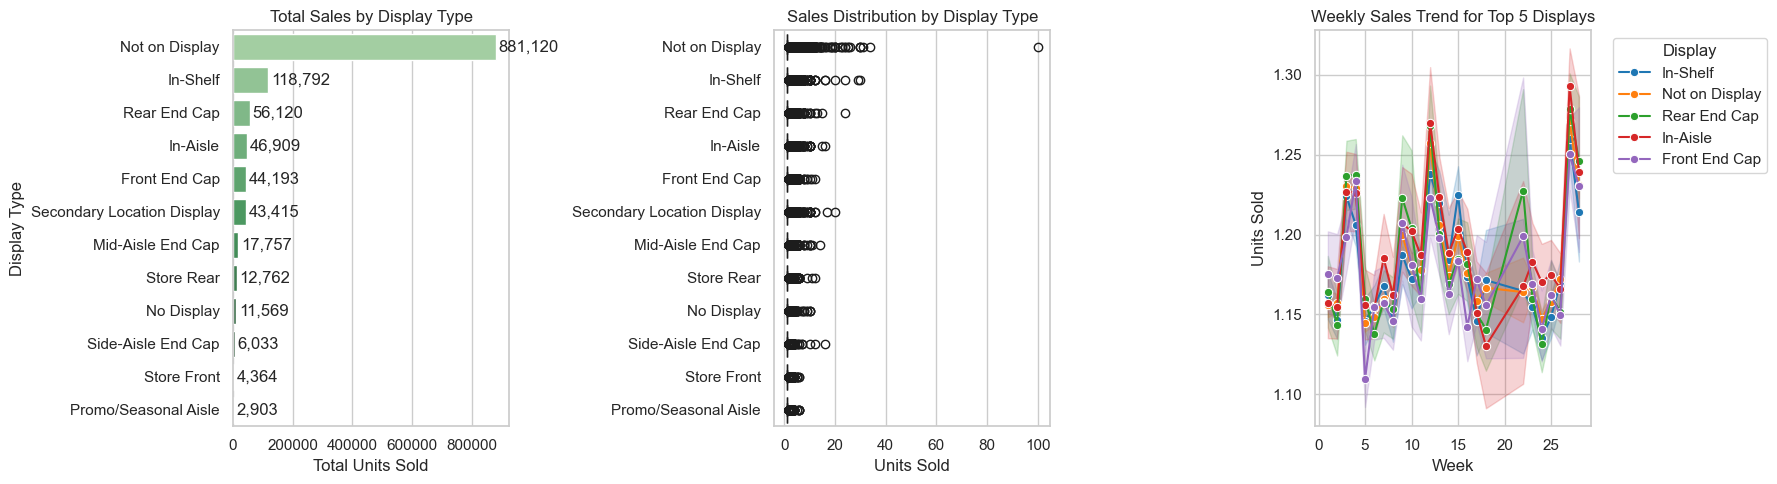

In [76]:
analyzer.plot_display_impact()

In [92]:
analyzer.print_unique_promotions()

🧾 Unique Feature Types:
['Not on Feature' 'Front Page Feature' 'Interior Page Feature'
 'No Feature' 'Wrap Interior Feature' 'Wrap Back Feature'
 'Interior Page Line Item' 'Wrap Front Feature']

🧾 Unique Display Types:
['In-Shelf' 'Not on Display' 'Secondary Location Display' 'No Display'
 'Rear End Cap' 'In-Aisle' 'Front End Cap' 'Mid-Aisle End Cap'
 'Store Rear' 'Side-Aisle End Cap' 'Promo/Seasonal Aisle' 'Store Front']


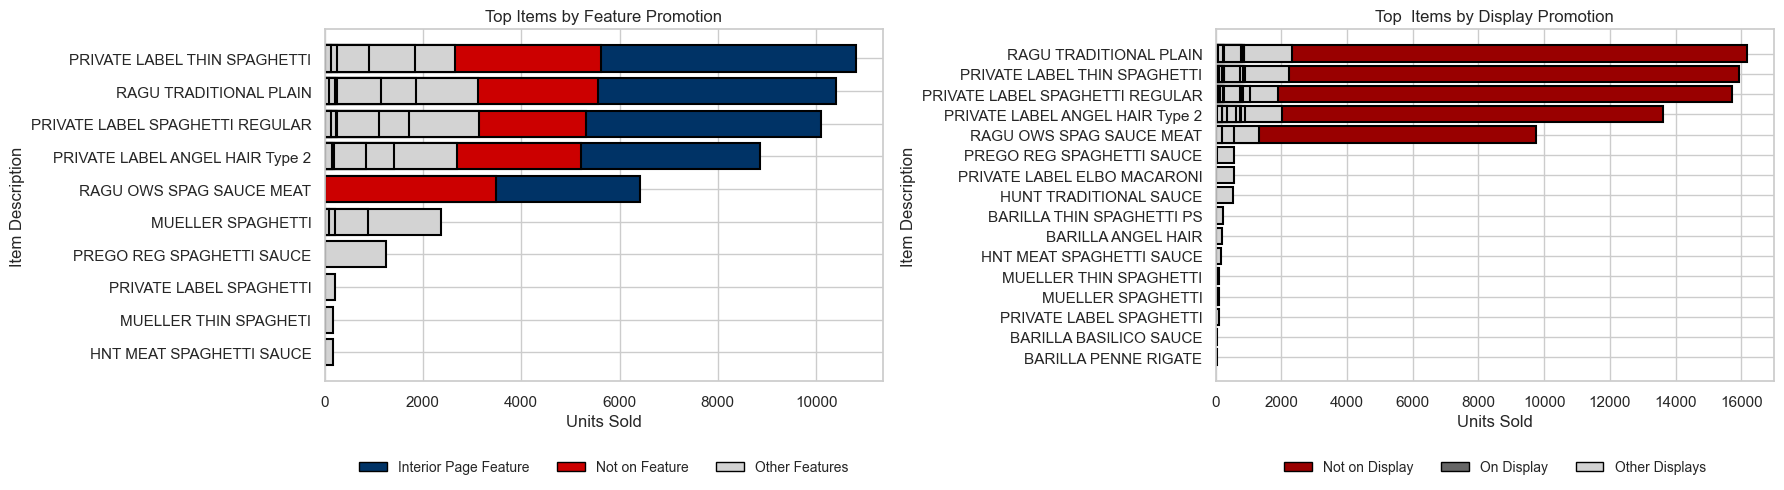

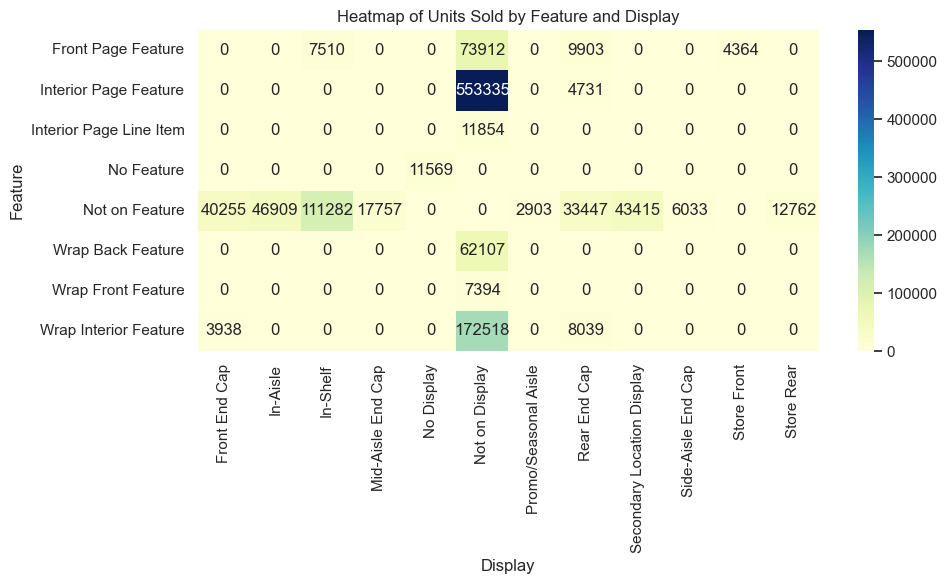

In [101]:
analyzer.plot_top_items_by_promotion()

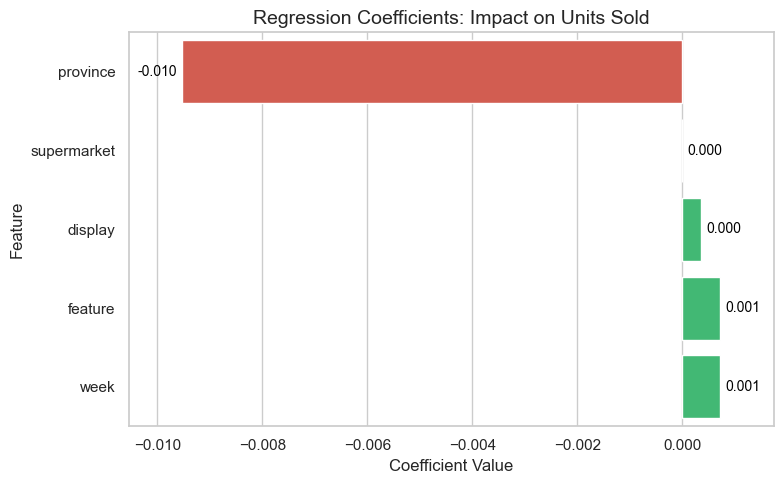

📊 Regression coefficients (sorted by impact):
    Feature   Coefficient
   province -9.521871e-03
supermarket  6.162424e-08
    display  3.566310e-04
    feature  7.186368e-04
       week  7.218347e-04


In [34]:
model, coefs = analyzer.run_regression()

### 🏬 Predicting High-Performing Supermarkets

---

- Define `high_performer` label based on sales threshold  
- Use transaction features to train a classification model  
- Predict and classify supermarkets as high or low performers  
- Evaluate with accuracy, precision, recall, and F1-score


Aggregating data...
Preparing features...
Training model...
=== Model Evaluation Metrics ===
Accuracy : 0.5789
Precision: 0.1667
Recall   : 0.1500
F1 Score : 0.1579

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        56
           1       0.17      0.15      0.16        20

    accuracy                           0.58        76
   macro avg       0.44      0.44      0.44        76
weighted avg       0.56      0.58      0.57        76



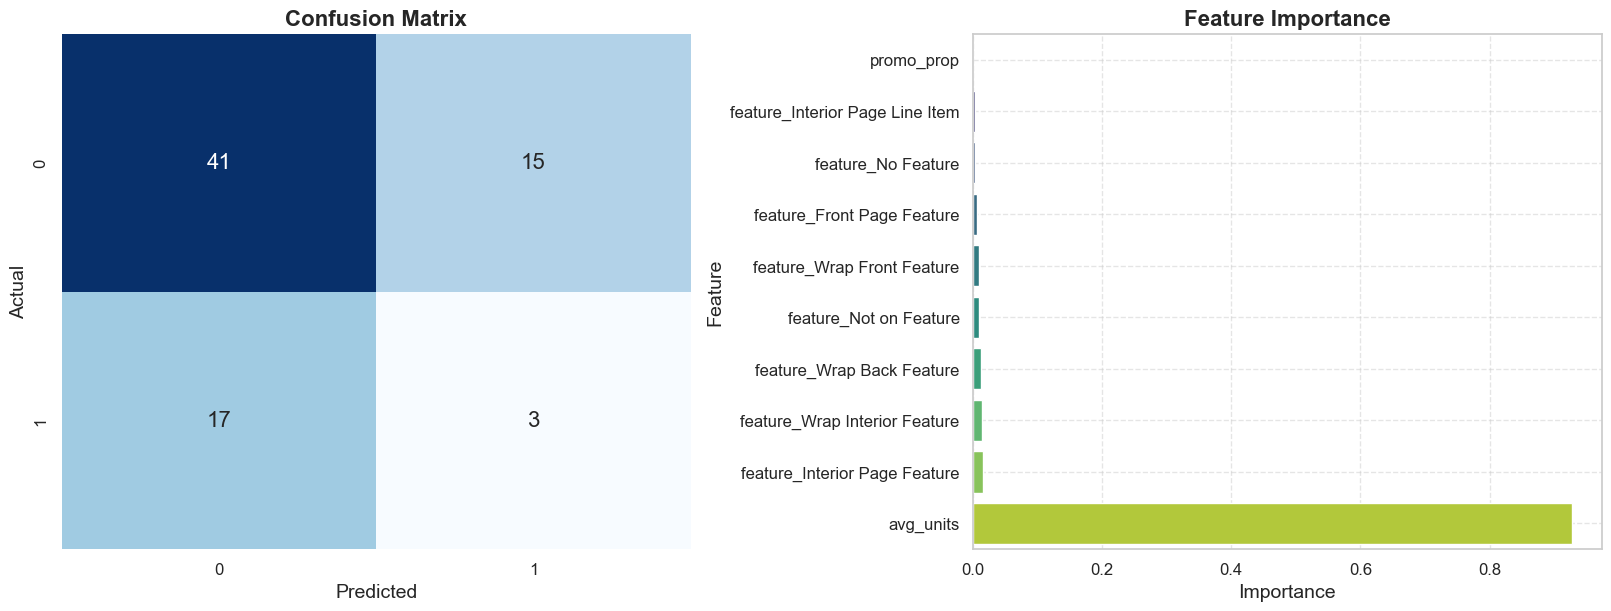

,supermarket,total_units,avg_units,promo_prop,most_freq_feature,high_performer
0,1,3506,1.210635,0,Wrap Interior Feature,0
1,2,3476,1.191227,0,Not on Feature,0
2,3,3777,1.187362,0,Wrap Interior Feature,0
3,4,2531,1.157823,0,Interior Page Feature,0
4,5,5207,1.200046,0,Interior Page Feature,1


In [ ]:
class SupermarketPerformancePredictor:
    def __init__(self, df):
        self.df = df.copy()
        self.supermarket_data = None
        self.model = None
        
    def aggregate_data(self):
        sales = self.df.groupby('supermarket')['units'].sum().rename('total_units')
        avg_units = self.df.groupby('supermarket')['units'].mean().rename('avg_units')
        promo_prop = self.df.groupby('supermarket')['promotion_active'].mean().rename('promo_prop') if 'promotion_active' in self.df.columns else pd.Series(0, index=sales.index, name='promo_prop')
        most_freq_feature = self.df.groupby('supermarket')['feature']\
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'No Feature')\
            .rename('most_freq_feature')
        
        self.supermarket_data = pd.concat([sales, avg_units, promo_prop, most_freq_feature], axis=1).reset_index()
        threshold = self.supermarket_data['total_units'].quantile(0.75)
        self.supermarket_data['high_performer'] = (self.supermarket_data['total_units'] >= threshold).astype(int)
        
    def prepare_features(self):
        feature_dummies = pd.get_dummies(self.supermarket_data['most_freq_feature'], prefix='feature')
        X = pd.concat([
            self.supermarket_data[['avg_units', 'promo_prop']],
            feature_dummies
        ], axis=1)
        y = self.supermarket_data['high_performer']
        return X, y
    
    def train_model(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        clf = RandomForestClassifier(random_state=42, n_estimators=100)
        clf.fit(X_train, y_train)
        self.model = clf
        
        y_pred = clf.predict(X_test)
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print("=== Model Evaluation Metrics ===")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}\n")
        
        print("=== Classification Report ===")
        print(classification_report(y_test, y_pred))
        
        # Create subplots side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
        
        # Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size":16})
        axes[0].set_title("Confusion Matrix", fontsize=16, fontweight='bold')
        axes[0].set_xlabel("Predicted", fontsize=14)
        axes[0].set_ylabel("Actual", fontsize=14)
        
        # Feature Importance Plot
        feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)
        sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', ax=axes[1])
        axes[1].set_title("Feature Importance", fontsize=16, fontweight='bold')
        axes[1].set_xlabel("Importance", fontsize=14)
        axes[1].set_ylabel("Feature", fontsize=14)
        
        # Add grid and style
        for ax in axes:
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.tick_params(axis='both', which='major', labelsize=12)
        
        plt.show()
        
        return clf, X_test, y_test, y_pred
    
    def run_all(self):
        print("Aggregating data...")
        self.aggregate_data()
        print("Preparing features...")
        X, y = self.prepare_features()
        print("Training model...")
        model, X_test, y_test, y_pred = self.train_model(X, y)
        return model, X_test, y_test, y_pred, self.supermarket_data



# === Usage ===
predictor = SupermarketPerformancePredictor(final_df)
model, X_test, y_test, y_pred, supermarket_summary = predictor.run_all()

# 3. If you want to inspect the aggregated supermarket data
supermarket_summary.head()